In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data we saved
# 'index_col=0' tells pandas the first column (Dates) is our index
# 'parse_dates=True' makes sure the computer knows they are real calendar dates
data = pd.read_csv("../data/processed/cleaned_financial_data.csv", index_col=0, parse_dates=True)

# Now you can easily grab Tesla and start Task 2
tsla = data['TSLA']
print("Data loaded from CSV. First few rows:")
print(tsla.head())

Data loaded from CSV. First few rows:
Date
2015-01-02    14.620667
2015-01-05    14.006000
2015-01-06    14.085333
2015-01-07    14.063333
2015-01-08    14.041333
Name: TSLA, dtype: float64


In [4]:


# 2. Chronological Split (Train: 2015-2024 | Test: 2025-2026)
train_end_date = "2024-12-31"
train = tsla[:train_end_date]
test = tsla[train_end_date:]

print(f"Loaded {len(tsla)} days of Tesla data.")

Loaded 2775 days of Tesla data.


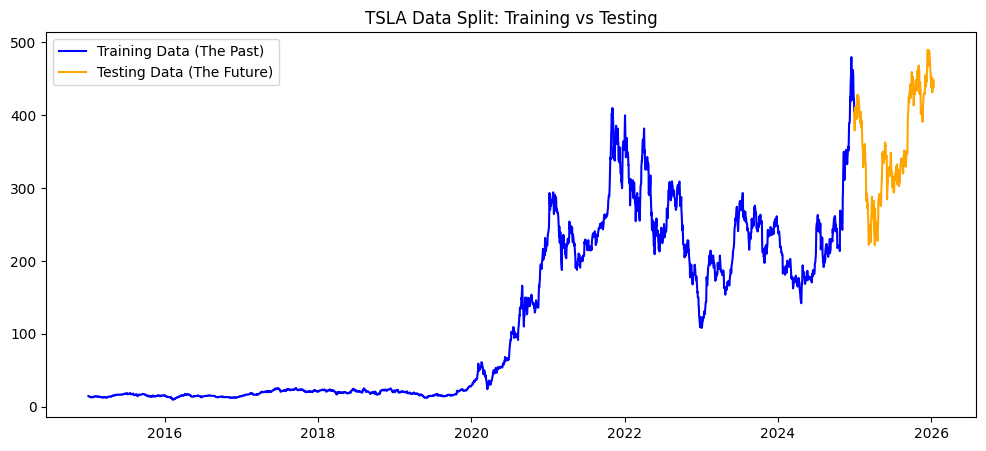

In [5]:
# Let's see how they look separately
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
plt.plot(train, label='Training Data (The Past)', color='blue')
plt.plot(test, label='Testing Data (The Future)', color='orange')
plt.title("TSLA Data Split: Training vs Testing")
plt.legend()
plt.show()

In [10]:
import pmdarima as pm

# The model 'searches' for the best parameters for us
# d=1 because we know from Task 1 that we need differencing to be stationary
model = pm.auto_arima(train, 
                      seasonal=False, 
                      stepwise=True, 
                      suppress_warnings=True, 
                      trace=True)

print(model.summary())

# Generate predictions for the 'Test' period
forecast = model.predict(n_periods=len(test))

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=16374.056, Time=9.32 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.31 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.06 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.37 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 11.669 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Sun, 25 Jan 2026   AIC                          16368.109
Time:                        23:16:33   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
   

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [7]:
%pip install pmdarima

   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/711.9 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------- 711.9/711.9 kB 1.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 4.9 MB/s eta 0:00:01
   ------------------- -------------------- 1.3/2.8 MB 3.7 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 3.1 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.8 MB 2.8 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.8 MB 2.7 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 2.4 MB/s eta 0:00:00

   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
   ---------------------------------------- 0/2 [Cython]
 


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [8]:
!python -m pip install ipykernel
!python -m ipykernel install --user --name=myvenv --display-name "Python (myvenv)"

  Using cached ipykernel-7.1.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached comm-0.2.3-py3-none-any.whl.metadata (3.7 kB)
  Using cached jupyter_core-5.9.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached matplotlib_inline-0.2.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached nest_asyncio-1.6.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached psutil-7.2.1-cp37-abi3-win_amd64.whl.metadata (23 kB)
  Using cached pyzmq-27.1.0-cp312-abi3-win_amd64.whl.metadata (6.0 kB)
  Using cached tornado-6.5.4-cp39-abi3-win_amd64.whl.metadata (2.9 kB)
  Using cached traitlets-5.14.3-py3-none-any.whl.metadata (10 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl.metadata (17 kB)
  Using cached decorator-5.2.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached ipython_pygments_lexers-1.1.1-py3-none-any.whl.metadata (1.1 kB)
  Using cached jedi-0.19.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached prompt_toolkit-3.0.52-py3-none-any.whl.metadata (6.4 kB)
  Using cached stack_data-0.6.3-p


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Installed kernelspec myvenv in C:\Users\hp\AppData\Roaming\jupyter\kernels\myvenv


In [9]:
import pmdarima as pm
print("It works!")

It works!


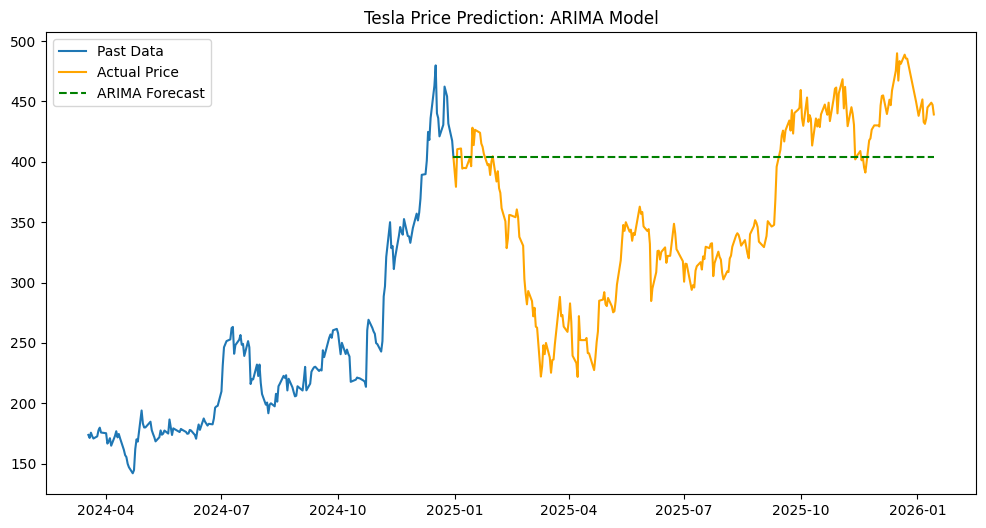

In [11]:
plt.figure(figsize=(12, 6))
plt.plot(train.tail(200), label="Past Data")
plt.plot(test.index, test, label="Actual Price", color='orange')
plt.plot(test.index, forecast, label="ARIMA Forecast", color='green', linestyle='--')
plt.title("Tesla Price Prediction: ARIMA Model")
plt.legend()
plt.show()

In [12]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Initialize the scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 2. Reshape and scale the training data
# We only 'fit' on the training data to avoid 'cheating' by seeing the future test prices
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))

# 3. Scale the test data using the same rules
test_scaled = scaler.transform(test.values.reshape(-1, 1))

print("Data scaled successfully between 0 and 1.")

Data scaled successfully between 0 and 1.


In [13]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# Prepare the training sequences
X_train, y_train = create_sequences(train_scaled)

# Prepare the testing sequences (using some of the end of training data to predict the first test days)
full_data_scaled = np.vstack((train_scaled[-60:], test_scaled))
X_test, y_test = create_sequences(full_data_scaled)

# Reshape for LSTM: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Sequences created! Training shape: {X_train.shape}")

Sequences created! Training shape: (2456, 60, 1)


In [19]:
pip install tensorflow

  Using cached tensorflow-2.20.0-cp313-cp313-win_amd64.whl.metadata (4.6 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached wrapt-2.0.1-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
  Using cached grpcio-1.76.0-cp313-cp313-win_amd64.whl.metadata (3.8 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.13.1-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.15.1-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
  Using cached ml_dtypes


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\hp\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Initialize the AI model
model = Sequential()

# 2. Add the first LSTM layer
# 'units=50' is like the number of "neurons" thinking about the patterns
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2)) # This turns off 20% of neurons randomly to help it learn better

# 3. Add a second LSTM layer (more depth for complex patterns)
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# 4. Add the final "Decision" layer (predicting 1 price)
model.add(Dense(units=1))

# 5. Compile the model
# 'adam' is a smart optimizer, and we measure error using 'mean_squared_error'
model.compile(optimizer='adam', loss='mean_squared_error')

print(model.summary())

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

None


In [21]:
# This part might take 1-2 minutes depending on your computer
history = model.fit(X_train, y_train, 
                    epochs=25, 
                    batch_size=32, 
                    validation_split=0.1, # Keep 10% aside to check its progress
                    verbose=1)

Epoch 1/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 90s 76ms/step - loss: 0.0092 - val_loss: 0.0037
Epoch 2/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 0.0021 - val_loss: 0.0028
Epoch 3/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0017 - val_loss: 0.0026
Epoch 4/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - loss: 0.0016 - val_loss: 0.0029
Epoch 5/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 0.0015 - val_loss: 0.0029
Epoch 6/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0014 - val_loss: 0.0036
Epoch 7/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - loss: 0.0014 - val_loss: 0.0024
Epoch 8/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0013 - val_loss: 0.0018
Epoch 9/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 10/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 11/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0012 - val_loss: 0.0019
Epoch 12/25
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 0.

9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step


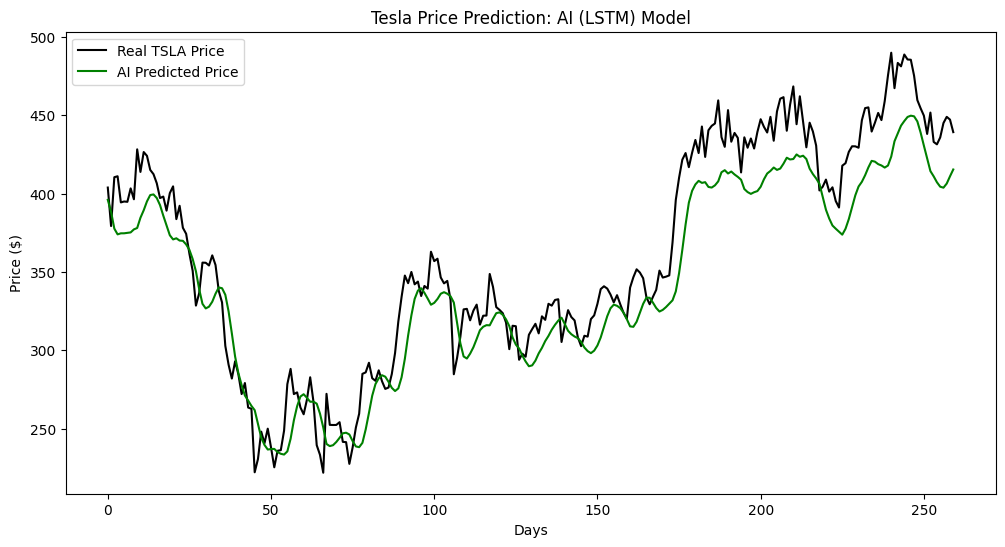

In [22]:
# 1. Make predictions on the test set
predictions = model.predict(X_test)

# 2. Un-squash the numbers back to real prices
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Plot the final result
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, color='black', label="Real TSLA Price")
plt.plot(predicted_prices, color='green', label="AI Predicted Price")
plt.title("Tesla Price Prediction: AI (LSTM) Model")
plt.xlabel("Days")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- ARIMA Metrics ---
# (Note: forecast was calculated in the ARIMA step)
arima_mae = mean_absolute_error(test, forecast)
arima_rmse = np.sqrt(mean_squared_error(test, forecast))
arima_mape = np.mean(np.abs((test - forecast) / test)) * 100

# --- LSTM Metrics ---
# (Note: actual_prices and predicted_prices were calculated in the LSTM step)
lstm_mae = mean_absolute_error(actual_prices, predicted_prices)
lstm_rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))
lstm_mape = np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100

# Create the Comparison Table
comparison_data = {
    "Metric": ["MAE (Mean Absolute Error)", "RMSE (Root Mean Squared Error)", "MAPE (Percentage Error)"],
    "ARIMA Model": [arima_mae, arima_rmse, arima_mape],
    "LSTM Model": [lstm_mae, lstm_rmse, lstm_mape]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

C:\Users\hp\AppData\Local\Temp\ipykernel_16476\3271418064.py:8: RuntimeWarning: '<' not supported between instances of 'int' and 'Timestamp', sort order is undefined for incomparable objects.
  arima_mape = np.mean(np.abs((test - forecast) / test)) * 100


                           Metric  ARIMA Model  LSTM Model
0       MAE (Mean Absolute Error)    69.231653   21.276396
1  RMSE (Root Mean Squared Error)    82.774970   25.726252
2         MAPE (Percentage Error)          NaN    5.745356


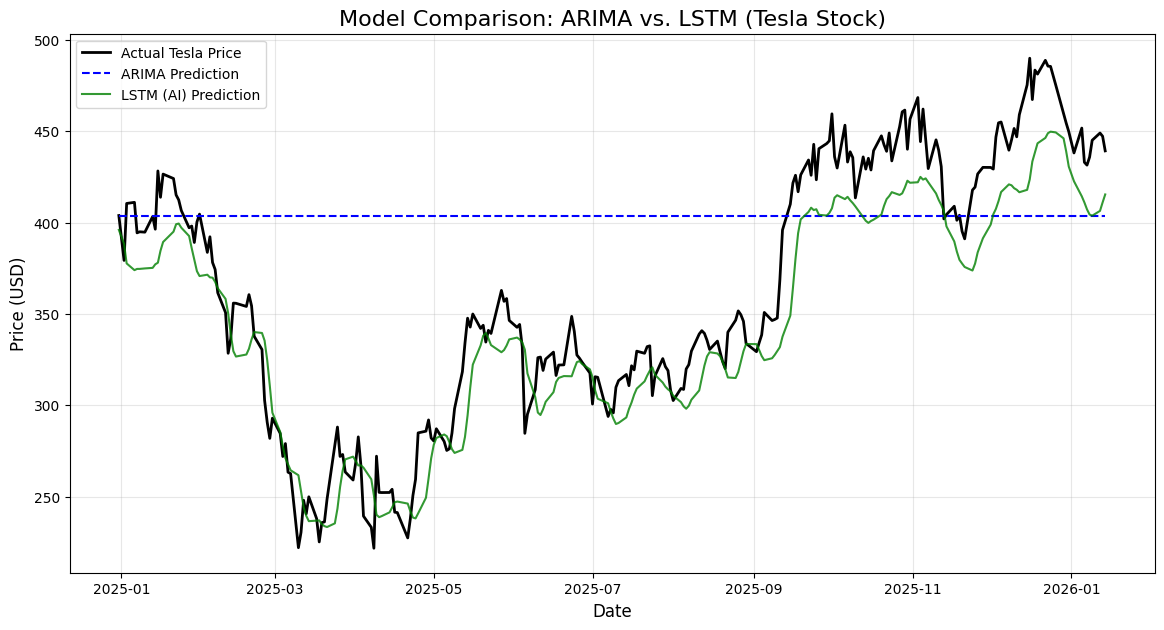

In [24]:
import matplotlib.pyplot as plt

# 1. Set the size of the graph
plt.figure(figsize=(14, 7))

# 2. Plot the Actual Prices (The Truth)
plt.plot(test.index, test.values, label="Actual Tesla Price", color='black', linewidth=2)

# 3. Plot the ARIMA Forecast (The Classical Model)
# ARIMA usually gives a smoother, simpler line
plt.plot(test.index, forecast, label="ARIMA Prediction", color='blue', linestyle='--')

# 4. Plot the LSTM Prediction (The AI Model)
# LSTM usually follows the "wiggles" of the market more closely
# Note: We use [-len(predicted_prices):] to make sure the dates match exactly
plt.plot(test.index[-len(predicted_prices):], predicted_prices, label="LSTM (AI) Prediction", color='green', alpha=0.8)

# 5. Add titles and labels to make it easy to read
plt.title("Model Comparison: ARIMA vs. LSTM (Tesla Stock)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (USD)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 6. Show the graph!
plt.show()

In [26]:
import numpy as np

# Convert to numpy arrays to remove the index/label confusion
actual = test.values
predicted = np.array(forecast)

# Calculate MAPE: average of |(actual - predicted) / actual|
arima_mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"Corrected ARIMA MAPE: {arima_mape:.2f}%")

Corrected ARIMA MAPE: 22.47%
